# A first EM algorithm

We observe 12 batches of ten coin tosses. Each batch came from coin A or coin B, but the coin label was not recorded. We want to estimate the two head probabilities.

The head count is observed. The coin label is a **latent variable**. The two head probabilities are unknown parameters.

EM estimates unknown parameters by averaging over the missing labels.

In [1]:
heads <- c(1, 8, 3, 6, 5, 2, 9, 4, 7, 5, 3, 7)
n_tosses <- 10

data.frame(
  batch = seq_along(heads),
  heads = heads,
  tails = n_tosses - heads
)

batch,heads,tails
<int>,<dbl>,<dbl>
1,1,9
2,8,2
3,3,7
4,6,4
5,5,5
6,2,8
7,9,1
8,4,6
9,7,3


## Start with the case we could solve by counting

Let $z_i=1$ when batch $i$ came from coin A and $z_i=0$ otherwise. If these labels were known, the maximum likelihood estimates would be

$$
\hat p_A = \frac{\sum_i z_i x_i}{m\sum_i z_i},
\qquad
\hat p_B = \frac{\sum_i (1-z_i)x_i}{m\sum_i (1-z_i)},
$$

where $x_i$ is the number of heads and $m=10$ is the number of tosses. This is ordinary counting. The only obstacle is that $z_i$ is missing.

## E step: give each possible label a probability

We fix the prior probability of each coin at $1/2$. Given current values of $p_A$ and $p_B$, Bayes' rule gives

$$
r_i = P(z_i=1\mid x_i)
= \frac{\operatorname{Bin}(x_i;m,p_A)}
{\operatorname{Bin}(x_i;m,p_A)+\operatorname{Bin}(x_i;m,p_B)}.
$$

The value $r_i$ is a fractional assignment to coin A, not a hard label.

In [2]:
responsibility <- function(heads, n_tosses, p_A, p_B) {
  prob_A <- 0.5 * dbinom(heads, size = n_tosses, prob = p_A)
  prob_B <- 0.5 * dbinom(heads, size = n_tosses, prob = p_B)
  prob_A / (prob_A + prob_B)
}

## M step: count with fractional labels

Replace each missing $z_i$ with its probability $r_i$ and use the same counting estimates.

$$
p_A \leftarrow \frac{\sum_i r_i x_i}{m\sum_i r_i},
\qquad
p_B \leftarrow \frac{\sum_i (1-r_i)x_i}{m\sum_i (1-r_i)}.
$$

The E step updates the label probabilities. The M step updates the head probabilities. Repeat until the estimates stop changing.

In [3]:
update_probabilities <- function(heads, n_tosses, r) {
  c(
    p_A = sum(r * heads) / (n_tosses * sum(r)),
    p_B = sum((1 - r) * heads) / (n_tosses * sum(1 - r))
  )
}

observed_loglik <- function(heads, n_tosses, p_A, p_B) {
  prob_A <- 0.5 * dbinom(heads, size = n_tosses, prob = p_A)
  prob_B <- 0.5 * dbinom(heads, size = n_tosses, prob = p_B)
  sum(log(prob_A + prob_B))
}

fit_em <- function(heads, n_tosses, p_start = c(0.2, 0.8),
                   tolerance = 1e-10, max_iter = 200) {
  p_A <- p_start[1]
  p_B <- p_start[2]
  history <- data.frame(
    iteration = 0L,
    p_A = p_A,
    p_B = p_B,
    loglik = observed_loglik(heads, n_tosses, p_A, p_B)
  )

  for (iteration in seq_len(max_iter)) {
    r <- responsibility(heads, n_tosses, p_A, p_B)
    updated <- update_probabilities(heads, n_tosses, r)
    change <- max(abs(updated - c(p_A, p_B)))
    p_A <- unname(updated[["p_A"]])
    p_B <- unname(updated[["p_B"]])

    history <- rbind(
      history,
      data.frame(
        iteration = iteration,
        p_A = p_A,
        p_B = p_B,
        loglik = observed_loglik(heads, n_tosses, p_A, p_B)
      )
    )

    if (change < tolerance) break
  }

  list(
    probabilities = c(p_A = p_A, p_B = p_B),
    responsibility = responsibility(heads, n_tosses, p_A, p_B),
    history = history
  )
}

In [4]:
fit <- fit_em(heads, n_tosses)

result <- data.frame(
  batch = seq_along(heads),
  heads = heads,
  probability_coin_A = round(fit$responsibility, 3)
)

cat(sprintf(
  "Estimated head probabilities: p_A = %.3f, p_B = %.3f\n",
  fit$probabilities[["p_A"]],
  fit$probabilities[["p_B"]]
))
result

negative_loglik <- function(theta) {
  p <- sort(plogis(theta))
  -observed_loglik(heads, n_tosses, p[1], p[2])
}
direct_fit <- optim(
  qlogis(fit$probabilities),
  negative_loglik,
  control = list(reltol = 1e-12)
)
direct_probabilities <- sort(plogis(direct_fit$par))

stopifnot(all(diff(fit$history$loglik) >= -1e-10))
stopifnot(max(abs(fit$probabilities - direct_probabilities)) < 1e-5)

Estimated head probabilities: p_A = 0.312, p_B = 0.688


batch,heads,probability_coin_A
<int>,<dbl>,<dbl>
1,1,0.998
2,8,0.009
3,3,0.959
4,6,0.171
5,5,0.500
6,2,0.991
7,9,0.002
8,4,0.829
9,7,0.041


## Why the repetition helps

The E step uses the current head probabilities to interpret each batch. The M step uses those interpretations to improve the probabilities. Each cycle increases, or leaves unchanged, the likelihood of the observed head counts.

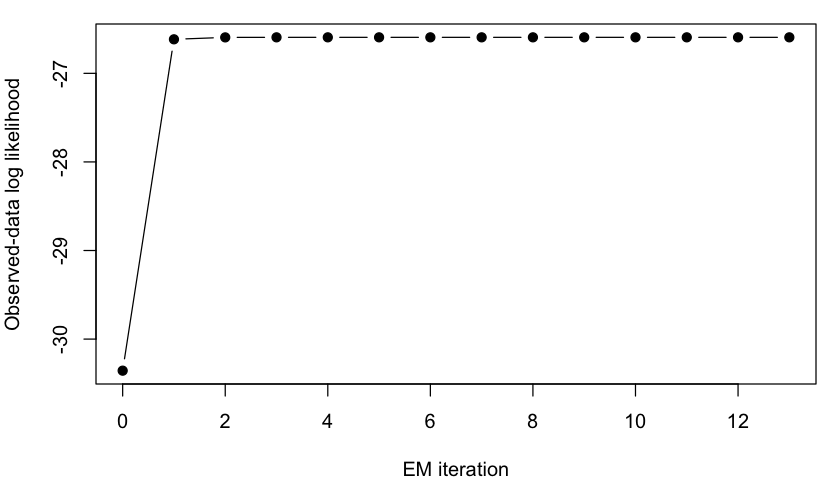

In [5]:
options(repr.plot.width = 7, repr.plot.height = 4)
par(mar = c(4, 4, 1, 1))
plot(
  fit$history$iteration,
  fit$history$loglik,
  type = "b",
  pch = 19,
  xlab = "EM iteration",
  ylab = "Observed-data log likelihood"
)

## What to remember

1. With known coin labels, both head probabilities are estimated by counting.
2. The E step replaces each missing label with a posterior probability.
3. The M step uses those probabilities as fractional counts.
4. The [genotyping-error example](P8149_Lecture_2_MAF_MLE_EM.ipynb) uses the same logic when the true genotype is latent and the genotype call is the measurement.

### Further reading

- Dempster, Laird, and Rubin (1977), *Maximum Likelihood from Incomplete Data via the EM Algorithm*.